## CIRCUITO 1

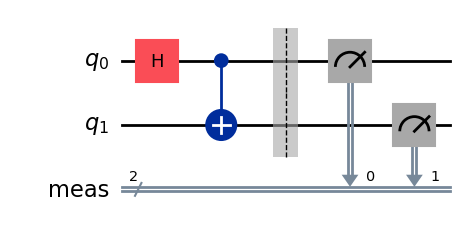

In [8]:
from qiskit import QuantumCircuit 
import matplotlib.pyplot as plt 
qc = QuantumCircuit(2) 
qc.h(0) 
qc.cx(0, 1) 
qc.measure_all() 
qc.draw("mpl") 


## PRUEBA DE UN SIMULADOR

Matrix product state

In [3]:
import numpy as np

# Import Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Construct quantum circuit
circ = QuantumCircuit(2, 2)
circ.h(0)
circ.cx(0, 1)
circ.measure([0,1], [0,1])

# Select the AerSimulator from the Aer provider
simulator = AerSimulator(method='matrix_product_state')

# Run and get counts, using the matrix_product_state method
tcirc = transpile(circ, simulator)
result = simulator.run(tcirc).result()
counts = result.get_counts(0)
counts

{'11': 494, '00': 530}

In [4]:
circ = QuantumCircuit(2, 2)
circ.h(0)
circ.cx(0, 1)

# Define a snapshot that shows the current state vector
circ.save_statevector(label='my_sv')
circ.save_matrix_product_state(label='my_mps')
circ.measure([0,1], [0,1])

# Execute and get saved data
tcirc = transpile(circ, simulator)
result = simulator.run(tcirc).result()
data = result.data(0)

#print the result data
data

{'counts': {'0x3': 503, '0x0': 521},
 'my_sv': Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
              0.70710678+0.j],
             dims=(2, 2)),
 'my_mps': ([(array([[1.-0.j, 0.-0.j]]), array([[0.-0.j, 1.-0.j]])),
   (array([[1.-0.j],
           [0.-0.j]]),
    array([[0.-0.j],
           [1.-0.j]]))],
  [array([0.70710678, 0.70710678])])}

## CIRCUITO3: 

ESTADO DE BELL CON DOS QUIT Y EJECUCIÓN EN ESTIMATOR

https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-3-hello-world.ipynb
https://www.youtube.com/watch?v=93-zLTppFZw&list=PLZIvznntA6uKiXmqwd9xEWAWK0CUhtImA&index=1&t=48s


https://quantum.cloud.ibm.com/docs/es/tutorials/hello-world

**Step 1: Map the problem to circuits and operators**

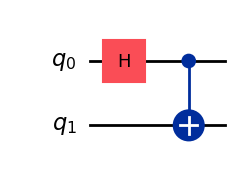

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw(output='mpl')
# No he ejecutado el circuito, pero si lo hiciera, obtendría un estado de Bell 
# entre los dos qubits.

In [2]:
from qiskit.quantum_info import Pauli
# Paulis para medir correlaciones entre qubits, esto significa
# que se pueden medir correlaciones entre los qubits en un estado de Bell.
# Las correlaciones significan que si se mide un qubit, el otro qubit
# tendrá un valor correlacionado con el primero, incluso si están separados
# por una gran distancia. Esto es lo que se conoce como entrelazamiento cuántico.
# Los estados de Bell son un ejemplo de entrelazamiento cuántico.

# Pauli ZZ significa que se mide el primer qubit en la base Z y el segundo qubit en la base Z.
ZZ = Pauli('ZZ')
# Pauli ZI significa que se mide el primer qubit en la base Z y el segundo qubit en la base I 
# (identidad).
ZI = Pauli('ZI')
# Pauli IZ significa que se mide el primer qubit en la base I (identidad) y el segundo qubit 
# en la base Z.
IZ = Pauli('IZ')
# Pauli XX significa que se mide el primer qubit en la base X y el segundo qubit en la base X.
XX = Pauli('XX')
# Pauli IX significa que se mide el primer qubit en la base I (identidad) y el segundo qubit
# en la base X.
XI = Pauli('XI')
# Pauli XI significa que se mide el primer qubit en la base X y el segundo qubit en la base 
# I (identidad).
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]

**Step 2: Optimize**

no permite optimizar no tiene conexión

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

**Step 3: Execute on the backend**

In [3]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()

job = estimator.run([qc] * len(observables), observables)

job.result()

EstimatorResult(values=array([1.        , 0.0390625 , 0.0390625 , 1.        , 0.01367188,
       0.01367188]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'time_taken': 0.006843906, 'num_bind_params': 1, 'parallel_state_update': 4, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 2, 'sample_measure_time': 0.000832257, 'active_input_qubits': [0, 1], 'num_clbits': 2, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 7909, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.99847412109375, 'simulator_metadata': [{'time_taken': 0.006843906, 'num_bind_params': 1, 'parallel_state_update': 4, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 2, 'sample_measure_time': 0.000832257, 

**Step 4: Post-process (and plotting)**

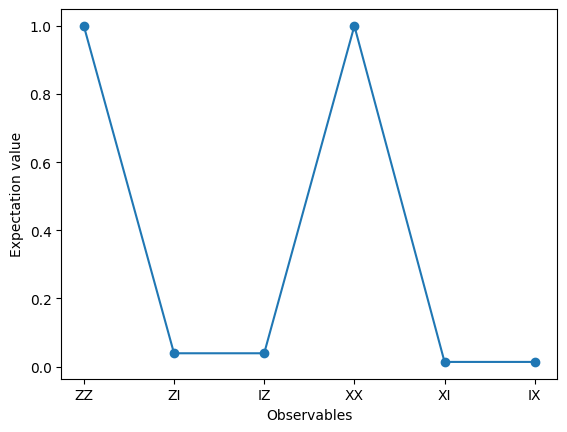

In [4]:
import matplotlib.pyplot as plt

data = ['ZZ', 'ZI', 'IZ', 'XX', 'XI', 'IX']
values = job.result().values

plt.plot(data, values, '-o')
plt.xlabel('Observables')
plt.ylabel('Expectation value')
plt.show()

continuar 
https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-3-hello-world.ipynb

## CIRCUITO 4

https://www.youtube.com/watch?v=93-zLTppFZw&list=PLZIvznntA6uKiXmqwd9xEWAWK0CUhtImA&index=1&t=48s

https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-3-hello-world.ipynb

https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/Coding_With_Qiskit/ep4_Gates.ipynb

https://www.youtube.com/watch?v=RrUTwq5jKM4
https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/Coding_With_Qiskit/ep3_Hello_World.ipynb


## CIRCUITO 4


In [5]:
from IPython.display import IFrame
IFrame(src="http://www.youtube.com/embed/tBnWG_95F9c", width=1920/2, height=1080/2)

In [6]:
from qiskit import *
circuit = QuantumCircuit(1,1)
circuit.x(0)

In [9]:
from qiskit_aer import AerSimulator

In [10]:
simulator = Aer.get_backend('unitary_simulator')
result = execute(circuit, backend=simulator).result()
unitary = result.get_unitary()
print(unitary)

NameError: name 'Aer' is not defined

In [8]:
from qiskit import *
circuit = QuantumCircuit(1,1)
circuit.x(0)
simulator = Aer.get_backend('statevector_simulator')
result = execute(circuit, backend=simulator).result()
statevector = result.get_statevector()
print(statevector)

NameError: name 'Aer' is not defined

## CIRCUITO 5

conexiones con token o apikey

In [11]:
import json
with open('/home/miguel/pruebasQiskit/apikey.json', 'r') as f:
        config = json.load(f)
token= config['token']
token

'eyJraWQiOiIyMDE5MDcyNCIsImFsZyI6IlJTMjU2In0.eyJpYW1faWQiOiJJQk1pZC02OTcwMDBTVENXI  iwiaWQiOiJJQk1pZC02OTcwMDBTVENXIiwicmVhbG1pZCI6IklCTWlkIiwianRpIjoiMTkyMGEyMzMtNTQ3Mi00ZWI2LWJjOWU  tMTRjN2M2MjY1ZGU2IiwiaWRlbnRpZmllciI6IjY5NzAwMFNUQ1ciLCJnaXZlbl9uYW1lIjoiTWlndWVsIMOBbmdlbCIsImZhb  WlseV9uYW1lIjoiUnViaW8gZGUgRGllZ28iLCJuYW1lIjoiTWlndWVsIMOBbmdlbCBSdWJpbyBkZSBEaWVnbyIsImVtYWlsIjo  iaW1hcmRpZWdvQGdtYWlsLmNvbSIsInN1YiI6ImltYXJkaWVnb0BnbWFpbC5jb20iLCJhdXRobiI6eyJzdWIiOiJpbWFyZGllZ  29AZ21haWwuY29tIiwiaWFtX2lkIjoiSUJNaWQtNjk3MDAwU1RDVyIsIm5hbWUiOiJNaWd1ZWwgw4FuZ2VsIFJ1YmlvIGRlIER  pZWdvIiwiZ2l2ZW5fbmFtZSI6Ik1pZ3VlbCDDgW5nZWwiLCJmYW1pbHlfbmFtZSI6IlJ1YmlvIGRlIERpZWdvIiwiZW1haWwiO  iJpbWFyZGllZ29AZ21haWwuY29tIn0sImFjY291bnQiOnsidmFsaWQiOnRydWUsImJzcyI6IjVhOTY2YjJhZjQyYTQ2MTE5YWV  mMTJmYTEzYTc0NDA0IiwiZnJvemVuIjp0cnVlfSwiaWF0IjoxNzU0MzMyNzk1LCJleHAiOjE3NTQzMzYzOTUsImlzcyI6Imh0d  HBzOi8vaWFtLmNsb3VkLmlibS5jb20vaWRlbnRpdHkiLCJncmFudF90eXBlIjoidXJuOmlibTpwYXJhbXM6b2F1dGg6Z3JhbnQ  tdHlwZTphcGlrZXk

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum", token=token)